<a href="https://colab.research.google.com/github/gssgsssss/Projet_Arbres_Decision_L3/blob/main/Projet_Maths_Info_Arbres_Decision_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Projet Mathématiques-Informatique S6
## Implémentation d'un Arbre de Décision pour le Diagnostic Clinique
**Parcours :** Math-Info

**Enseignante :** Raquel Urena

**Étudiants :** KAMARA Aziz et CHAERYEONG Yeo

**Année universitaire :** 2025-2026

---
## Table des matières

1. [Introduction](#introduction)
2. [Dataset: Heart Disease Cleveland](#dataset)
3. [Théorie: Arbres de Décision](#theorie)
4. [Implémentation from Scratch](#implementation)
5. [Évaluation des Performances](#evaluation)
6. [Visualisation de l'Arbre](#visualisation)
7. [Analyse Critique](#analyse)

---

---
## 1. Introduction

Dans ce projet de licence L3 Maths-Info, nous allons implémenter une arbre de décision en Python sans aucune bibliothèque d'apprentissage automatique donc pas de scikit-learn, tensorflow, etc.

### Objectif

L'objectif ici est de construire un classificateur capable de prédire la présence d'une maladie cardiaque chez un patient, à partir de données cliniques. L'algorithme utilisé est CART (Classification and Regression Trees), basé sur le critère de Gini impurity.

### Pourquoi un arbre de décision ?

Nous choissisons une arbre décision elles démontrent plusieurs avantages dans un contexte clinique :
**L'interprétabilité** : Chaque décision pris est explicable noeud par noeud

**Pas de normalisation requise** : Les données n'ont pas besoin d'être mises à l'échelle avant l'entrainement du modèle

**Gestion native des variables mixtes** : continues et catégorielles

---
## 2. Dataset: Heart Disease Cleveland

### Source
Dataset disponible sur [Kaggle: Heart Disease Cleveland](https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland).

### Description
Le dataset contient 303 observations et 13 variables explicatives, sans valeurs manquantes.

| Variable | Type | Description |
|----------|------|-------------|
| **age** | Continue | Âge du patient (années) |
| **sex** | Binaire | Sexe (1 = homme, 0 = femme) |
| **cp** | Catégorielle | Type de douleur thoracique (0-3) |
| **trestbps** | Continue | Tension artérielle au repos (mmHg) |
| **chol** | Continue | Cholestérol sérique (mg/dl) |
| **fbs** | Binaire | Glycémie à jeun > 120 mg/dl (1 = vrai) |
| **restecg** | Catégorielle | Résultats ECG au repos (0-2) |
| **thalach** | Continue | Fréquence cardiaque maximale atteinte |
| **exang** | Binaire | Angine induite par l'exercice (1 = oui) |
| **oldpeak** | Continue | Dépression ST induite par l'exercice |
| **slope** | Catégorielle | Pente du segment ST (0-2) |
| **ca** | Catégorielle | Nombre de vaisseaux colorés (0-3) |
| **thal** | Catégorielle | Type de thalassémie (1-3) |
| **target** | Binaire | **Cible** : 1 = maladie, 0 = sain |

### Distribution des classes
- **Classe 0** (sain) : 164 patients (54%)
- **Classe 1** (maladie cardiaque) : 139 patients (46%)

Les classes sont bien équilibrées, pas de biais de déséquilibre à corriger.

---
## 3. Théorie: Arbres de Décision

### 3.1 Définition

Un arbre de décision est une structure arborescente ou chaque **noeud interne** représente un test sur une variable, chaque **branche** correspond au résultat du test et chaque **feuille** contient une classe prédite.

### 3.2 Algorithme CART

**CART (Classification and Regression Trees)** construit un arbre **binaire** : à chaque noeud, les données sont divisées en exactement deux sous-ensembles selon un seuil sur une variable.

À chaque noeud, on cherche le couple **(variable, seuil)** qui minimise l'impureté de Gini pondérée des deux sous-ensembles fils.

### 3.3 Gini Impurity

Pour un noeud $t$ contenant des exemples de $c$ classes :

$$G(t) = 1 - \sum_{i=1}^{c} p(i|t)^2$$

où $p(i|t)$ est la proportion d'exemples de la classe $i$ dans le noeud $t$.

- $G(t) = 0$ : noeud **pur** (une seule classe)
- $G(t) = 0.5$ : noeud **maximalement impur** (classes équiréparties)

### 3.4 Gini pondéré (critère de split)

Pour un split divisant un noeud parent en deux fils gauche ($L$) et droit ($R$) :

$$G_{split} = \frac{|L|}{|L|+|R|} \cdot G(L) + \frac{|R|}{|L|+|R|} \cdot G(R)$$

On choisit le split qui **minimise** $G_{split}$.

### 3.5 Critères d'arrêt (Pruning implicite)

Pour éviter le surapprentissage, la croissance de l'arbre est stoppée si :
- La profondeur maximale **max_depth** est atteinte
- Le nombre d'exemples dans un noeud est inférieur à **min_samples_split**
- Le noeud est déjà pur ($G(t) = 0$)

---
## 4. Implémentation from Scratch

*Les cellules de code suivantes implémentent intégralement l'algorithme CART en Python, sans bibliothèque de machine learning.*

---
## 5. Évaluation des Performances

*Les métriques suivantes sont également implémentées manuellement, sans scikit-learn.*

### Métriques utilisées
- **Matrice de confusion** : TP, TN, FP, FN
- **Précision** : $\frac{TP}{TP+FP}$
- **Rappel** : $\frac{TP}{TP+FN}$
- **F1-Score** : $2 \cdot \frac{\text{Précision} \cdot \text{Rappel}}{\text{Précision} + \text{Rappel}}$
- **ROC-AUC** : aire sous la courbe ROC

---
## 6. Visualisation de l'Arbre

*Représentation graphique de l'arbre construit, avec affichage des conditions de split, des valeurs de Gini, et des classes prédites à chaque feuille.*

---
## 7. Analyse Critique

### Limites du modèle
- Les arbres de décision sont sensibles au **surapprentissage** si la profondeur n'est pas contrôlée
- Un seul arbre est moins robuste qu'un ensemble (Random Forest, Gradient Boosting)
- Les splits sont toujours **axis-aligned** : CART ne peut pas créer de frontières diagonales

### Pistes d'amélioration
- Implémenter le **pruning post-croissance** (cost-complexity pruning)
- Tester différentes valeurs de **max_depth** et comparer les performances
- Comparer avec l'entropie comme critère alternatif à Gini

---

In [ ]:
# On importe pandas pour manipuler les données sous forme de tableau
import pandas as pd

# On charge le fichier CSV depuis Google Drive ou un upload direct
# Si le fichier est uploadé dans Colab, il sera dans /content/
df = pd.read_csv('https://raw.githubusercontent.com/gssgsssss/Projet_Arbres_Decision_L3/main/Heart_disease_cleveland_new.csv')

# On affiche les 5 premières lignes pour vérifier que le chargement est correct
print("Aperçu des données :")
display(df.head())

# On affiche les informations générales : types de colonnes, valeurs manquantes
print("\nInformations générales :")
df.info()

# On affiche des statistiques descriptives : min, max, moyenne, etc.
print("\nStatistiques descriptives :")
display(df.describe())

# On vérifie s'il y a des valeurs manquantes dans chaque colonne
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

# On affiche la distribution de la variable cible (0 = sain, 1 = malade)
print("\nDistribution de la variable cible :")
print(df['target'].value_counts())

Aperçu des données :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0



Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Statistiques descriptives :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000



Valeurs manquantes par colonne :
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Distribution de la variable cible :
target
0    164
1    139
Name: count, dtype: int64


## Description des variables

Le dataset contient 13 variables explicatives et 1 variable cible (**target**).

| Variable | Nom complet | Description |
|----------|-------------|-------------|
| **age** | Âge | Âge du patient en années |
| **sex** | Sexe | 1 = homme, 0 = femme |
| **cp** | Type de douleur thoracique | 0 = angine typique, 1 = angine atypique, 2 = douleur non-angineuse, 3 = asymptomatique |
| **trestbps** | Tension artérielle au repos | Pression artérielle au repos (mmHg) |
| **chol** | Cholestérol | Taux de cholestérol sérique (mg/dl) |
| **fbs** | Glycémie à jeun | 1 = glycémie > 120 mg/dl, 0 = normale |
| **restecg** | ECG au repos | 0 = normal, 1 = anomalie onde ST-T, 2 = hypertrophie ventriculaire gauche |
| **thalach** | Fréquence cardiaque maximale | Fréquence cardiaque maximale atteinte à l'effort |
| **exang** | Angine à l'effort | 1 = oui, 0 = non |
| **oldpeak** | Dépression ST | Dépression du segment ST induite par l'effort par rapport au repos |
| **slope** | Pente du segment ST | 0 = ascendante, 1 = plate, 2 = descendante |
| **ca** | Vaisseaux principaux | Nombre de vaisseaux principaux colorés par fluoroscopie (0-3) |
| **thal** | Thalassémie | 1 = normal, 2 = défaut fixe, 3 = défaut réversible |
| **target** | **Diagnostic** | **1 = maladie cardiaque, 0 = sain** |

La variable **target** est ce que notre arbre de décision cherche à prédire.
Les 13 autres variables sont les **features** utilisées pour construire les règles de décision.

In [ ]:
import numpy as np

# On sépare les features (X) de la variable cible (y)
X = df.drop(columns=['target']).values  # toutes les colonnes sauf target, converti en tableau numpy
y = df['target'].values                  # uniquement la colonne target

# On fixe une graine aléatoire pour que le split soit reproductible
# (même résultat à chaque exécution)
np.random.seed(42)

# On crée un tableau d'indices [0, 1, 2, ..., 302]
# puis on les mélange aléatoirement
indices = np.arange(len(X))
np.random.shuffle(indices)

# On calcule la taille du set d'entraînement (80% des données)
train_size = int(0.8 * len(X))  # 0.8 * 303 = 242 exemples

# On divise les indices en deux groupes
train_indices = indices[:train_size]   # les 242 premiers indices mélangés
test_indices = indices[train_size:]    # les 61 restants

# On applique ces indices pour créer X_train, X_test, y_train, y_test
X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

print(f"Taille train : {len(X_train)} exemples")
print(f"Taille test  : {len(X_test)} exemples")

Taille train : 242 exemples
Taille test  : 61 exemples


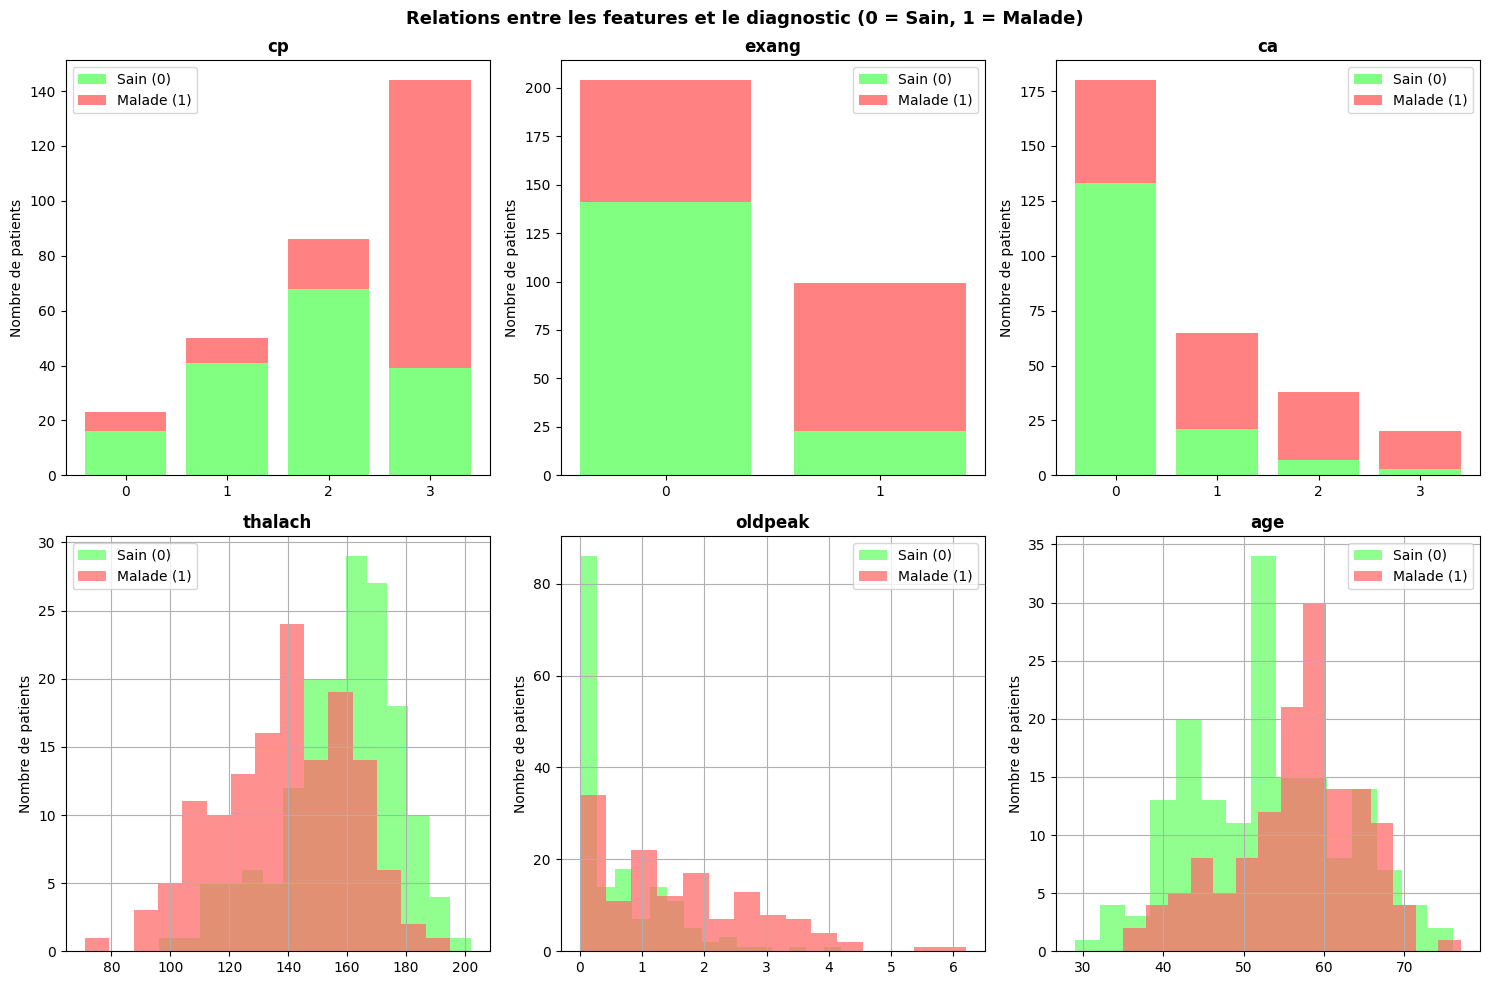

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Relations entre les features et le diagnostic (0 = Sain, 1 = Malade)',
             fontsize=13, fontweight='bold')

# --- Ligne 1 : features catégorielles ---
for i, feat in enumerate(['cp', 'exang', 'ca']):
    ax = axes[0, i]
    vals = sorted(df[feat].unique())
    sains   = [df[(df[feat] == v) & (df['target'] == 0)].shape[0] for v in vals]
    malades = [df[(df[feat] == v) & (df['target'] == 1)].shape[0] for v in vals]
    x = np.arange(len(vals))
    ax.bar(x, sains,   label='Sain (0)',    color='#6bff6b', alpha=0.85)
    ax.bar(x, malades, label='Malade (1)',  color='#ff6b6b', alpha=0.85,
           bottom=sains)
    ax.set_xticks(x)
    ax.set_xticklabels([int(v) for v in vals])
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Nombre de patients')
    ax.legend()

# --- Ligne 2 : features continues ---
for i, feat in enumerate(['thalach', 'oldpeak', 'age']):
    ax = axes[1, i]
    df[df['target'] == 0][feat].hist(ax=ax, bins=15, alpha=0.75,
                                      color='#6bff6b', label='Sain (0)')
    df[df['target'] == 1][feat].hist(ax=ax, bins=15, alpha=0.75,
                                      color='#ff6b6b', label='Malade (1)')
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Nombre de patients')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Exploration des Relations Features, Diagnostic

Ces graphiques montrent quelles variables séparent le mieux
les patients sains des patients malades.

### Variables catégorielles

**cp (type de douleur thoracique)**
Les patients avec cp = 3 (asymptomatique) sont majoritairement
malades — résultat contre-intuitif mais cohérent avec la
littérature clinique. C'est la variable la plus discriminante
du dataset, ce que confirmera le premier split de l'arbre CART.

**exang (angine à l'effort)**
Les patients avec exang = 1 (angine présente) sont très
majoritairement malades. Signal fort.

**ca (nombre de vaisseaux colorés)**
Plus ca est élevé, plus la proportion de malades augmente.
ca = 0 est associé à la santé, ca ≥ 1 à la maladie.

### Variables continues

**thalach (fréquence cardiaque maximale)**
Les patients malades ont une fréquence cardiaque maximale
plus basse que les patients sains. Les deux distributions
sont bien séparées.

**oldpeak (dépression ST)**
Une dépression ST élevée est fortement associée à la maladie.
Les patients sains ont quasi tous un oldpeak proche de 0.

**age**
Les deux distributions se chevauchent beaucoup — l'âge seul
est peu discriminant dans ce dataset.

### Conclusion de l'EDA

Les variables les plus discriminantes sont **cp**, **ca**,
**thalach** et **oldpeak**. Cette analyse justifie a posteriori
les premiers splits choisis par l'algorithme CART.

## Preprocessing: Préparation des données

Avant d'entraîner notre arbre de décision, il est nécessaire de préparer les données
en deux étapes : la séparation des features et de la cible, puis la division en
ensembles d'entraînement et de test.

### Séparation X / y

**X** contient les 13 variables explicatives (age, sex, cp, etc.) ce sont les
informations que l'arbre utilisera pour prendre ses décisions.

**y** contient uniquement la variable cible (**target**) c'est ce que l'arbre
cherche à prédire : 1 = maladie cardiaque, 0 = sain.

La méthode **.values** convertit le DataFrame pandas en tableau numpy,
format requis pour les opérations mathématiques qui suivent.

### Division train / test (80% / 20%)

On divise le dataset en deux parties :

**Ensemble d'entraînement (train)** : 242 exemples (80%) utilisés pour
  construire l'arbre
  
**Ensemble de test** : 61 exemples (20%) utilisés pour évaluer ses
  performances sur des données qu'il n'a jamais vues

### Pourquoi mélanger les indices plutôt que les données directement ?

Chaque patient a des features (X) et un diagnostic (y) qui doivent rester
associés. Si on mélangeait X et y séparément, on briserait ce lien les
features d'un patient se retrouveraient associées au diagnostic d'un autre.

En mélangeant un tableau d'indices [0, 1, 2, ..., 302] et en appliquant
le même ordre à X et y simultanément, on garantit que chaque patient
conserve son diagnostic correct tout au long du processus.

### Graine aléatoire (random seed)

**np.random.seed(42)** fixe la graine du générateur aléatoire. Cela garantit
que le mélange produit exactement le même résultat à chaque exécution du
notebook essentiel pour la reproductibilité des expériences.

In [ ]:
def gini_impurity(y):
    """
    Calcule la Gini impurity d'un ensemble de labels y.

    Exemple :
    - y = [0, 0, 0, 0] est Gini = 0.0 (noeud pur, une seule classe)
    - y = [0, 0, 1, 1] est Gini = 0.5 (noeud maximalement impur)
    """

    # Si le noeud est vide, l'impureté est 0
    if len(y) == 0:
        return 0

    # On compte le nombre total d'exemples dans ce noeud
    n = len(y)

    # On récupère les classes uniques présentes (ex: [0, 1])
    classes = np.unique(y)

    # On initialise la somme des p(i)²
    somme = 0

    # Pour chaque classe, on calcule sa proportion p(i) dans le noeud
    for c in classes:
        # p(i) = nombre d'exemples de la classe c / nombre total d'exemples
        p = np.sum(y == c) / n

        # On ajoute p(i)² à la somme
        somme += p ** 2

    # Gini = 1 - somme des p(i)²
    return 1 - somme


# Test rapide pour vérifier que la fonction est correcte
print(gini_impurity(np.array([0, 0, 0, 0])))  # Attendu : 0.0 (pur)
print(gini_impurity(np.array([0, 0, 1, 1])))  # Attendu : 0.5 (impur)
print(gini_impurity(np.array([0, 1, 1, 1])))  # Attendu : 0.375

0.0
0.5
0.375


### Gini Impurity

La Gini impurity mesure le degré d'impureté d'un noeud, c'est-à-dire à quel point
les exemples qu'il contient sont mélangés entre les différentes classes.

**Formule :**

G(t) = 1 - Σ p(i|t)²

Où p(i|t) est la proportion d'exemples de la classe i dans le noeud t.

**Cas limites :**
- G = 0.0 est un noeud **pur** : tous les exemples appartiennent à la même classe
- G = 0.5 est un noeud **maximalement impur** : les classes sont équiréparties

**Exemples :**
- [0, 0, 0, 0] est G = 0.0 (que des sains, noeud pur)
- [0, 0, 1, 1] est G = 0.5 (moitié sains, moitié malades)
- [0, 1, 1, 1] est G = 0.375 (majorité malades, légèrement impur)

**Intuition :**
À chaque noeud, CART cherche le split qui minimise la Gini impurity pondérée
des deux noeuds fils. Plus les fils sont purs, meilleur est le split.

In [ ]:
def gini_split(y_left, y_right):
    """
    Calcule la Gini impurity pondérée d'un split.

    y_left  : labels des exemples qui partent à gauche du split
    y_right : labels des exemples qui partent à droite du split
    """

    # Nombre total d'exemples dans les deux groupes combinés
    n_total = len(y_left) + len(y_right)

    # Poids de chaque groupe = sa taille / taille totale
    poids_left  = len(y_left)  / n_total
    poids_right = len(y_right) / n_total

    # Gini pondéré = poids_left × Gini(left) + poids_right × Gini(right)
    return poids_left * gini_impurity(y_left) + poids_right * gini_impurity(y_right)


# Test rapide
y_left  = np.array([0, 0, 0])  # groupe gauche : que des sains
y_right = np.array([1, 1, 0])  # groupe droit  : 2 malades, 1 sain

print(gini_split(y_left, y_right))  # Attendu : un nombre entre 0 et 0.5

0.2222222222222222


### Gini Pondéré (Weighted Gini)

Lorsqu'on effectue un split, on divise un noeud en deux groupes : gauche (L)
et droite (R). La Gini pondérée mesure la qualité globale de ce split.

**Formule :**

G_split = (|L| / |L|+|R|) × G(L) + (|R| / |L|+|R|) × G(R)

Chaque groupe est pondéré par sa taille relative , un grand groupe pur
compte plus qu'un petit groupe pur.

**Interprétation :**
- G_split = 0.0 est split parfait, chaque groupe ne contient qu'une seule classe
- G_split = 0.5 est pire split possible, les classes sont parfaitement mélangées
- G_split = 0.222 est bon split, les groupes sont bien séparés

**Exemple :**
- y_left  = [0, 0, 0] est Gini = 0.0 (groupe pur, que des sains)
- y_right = [1, 1, 0] est Gini = 0.444 (légèrement impur)
- G_split = 0.222 est bon résultat

**Contexte :**
Avant tout split, le dataset complet a une Gini d'environ 0.497 (très impur).
Obtenir 0.222 après un split représente une amélioration majeure.

CART teste tous les splits possibles sur toutes les features et conserve
celui qui produit la Gini pondérée la plus basse.

In [ ]:
def best_split(X, y):
    """
    Trouve le meilleur split possible sur toutes les features et tous les seuils.
    Retourne la feature, le seuil, et les indices gauche/droite du meilleur split.
    """

    best_gini = float('inf')  # on initialise avec l'infini, tout sera mieux
    best_feature = None       # index de la meilleure feature
    best_threshold = None     # meilleur seuil trouvé
    best_left = None          # indices des exemples allant à gauche
    best_right = None         # indices des exemples allant à droite

    n_features = X.shape[1]  # nombre de features (13 dans notre cas)

    # On boucle sur chaque feature
    for feature in range(n_features):

        # On récupère toutes les valeurs uniques de cette feature
        thresholds = np.unique(X[:, feature])

        # On teste chaque valeur unique comme seuil de split
        for threshold in thresholds:

            # On divise les indices en gauche (≤ seuil) et droite (> seuil)
            left_indices  = np.where(X[:, feature] <= threshold)[0]
            right_indices = np.where(X[:, feature] >  threshold)[0]

            # Si un des deux groupes est vide, ce split n'est pas valide
            if len(left_indices) == 0 or len(right_indices) == 0:
                continue

            # On calcule la Gini pondérée de ce split
            gini = gini_split(y[left_indices], y[right_indices])

            # Si c'est le meilleur split trouvé jusqu'ici, on le sauvegarde
            if gini < best_gini:
                best_gini      = gini
                best_feature   = feature
                best_threshold = threshold
                best_left      = left_indices
                best_right     = right_indices

    return best_feature, best_threshold, best_left, best_right, best_gini


# Test rapide sur les données d'entraînement
feature, threshold, left, right, gini = best_split(X_train, y_train)

print(f"Meilleure feature  : colonne {feature} ({df.columns[feature]})")
print(f"Meilleur seuil     : {threshold}")
print(f"Gini pondéré       : {gini:.4f}")
print(f"Taille gauche      : {len(left)}")
print(f"Taille droite      : {len(right)}")

Meilleure feature  : colonne 2 (cp)
Meilleur seuil     : 2.0
Gini pondéré       : 0.3593
Taille gauche      : 125
Taille droite      : 117


### Recherche du Meilleur Split

La fonction **best_split** teste tous les splits possibles sur toutes les
features et tous les seuils, et retourne celui qui minimise la Gini pondérée.

**Résultat obtenu :**

**Feature : colonne 2 (cp)**: le type de douleur thoracique est la variable
  la plus discriminante pour séparer les malades des sains

**Seuil : 2.0**: le split se fait à cp ≤ 2 (gauche) vs cp > 2 (droite)

**Gini pondérée : 0.3593**: amélioration significative par rapport au
  dataset complet (Gini ≈ 0.497 avant tout split)

**125 exemples à gauche**: patients avec cp ≤ 2

**117 exemples à droite**: patients avec cp > 2

**Interprétation clinique :**

cp représente le type de douleur thoracique :

cp ≤ 2 : angine typique, atypique, ou douleur non-angineuse

cp > 2 : asymptomatique (cp = 3)

Le fait que cp soit la première feature choisie par CART signifie que
la présence ou l'absence de douleur thoracique est le signal le plus
fort pour prédire une maladie cardiaque dans ce dataset.

**Comment fonctionne la recherche ?**

Pour chaque feature (13 au total), on teste chaque valeur unique comme
seuil. Pour cp, les valeurs uniques sont [0, 1, 2, 3], donc on teste
4 seuils. En tout, CART a testé tous les seuils de toutes les features
et c'est cp > 2.0 qui a produit la Gini la plus basse.

In [ ]:
def build_tree(X, y, depth=0, max_depth=3, min_samples_split=2):
    """
    Construit récursivement l'arbre de décision.

    X                : features des exemples du noeud courant
    y                : labels des exemples du noeud courant
    depth            : profondeur actuelle dans l'arbre
    max_depth        : profondeur maximale autorisée
    min_samples_split: nombre minimum d'exemples pour effectuer un split
    """

    # --- CONDITIONS D'ARRÊT ---

    # 1. Le noeud est pur : tous les exemples appartiennent à la même classe
    if len(np.unique(y)) == 1:
        return {'leaf': True, 'prediction': y[0]}

    # 2. On a atteint la profondeur maximale
    if depth >= max_depth:
        prediction = np.bincount(y).argmax()  # classe majoritaire
        return {'leaf': True, 'prediction': prediction}

    # 3. Pas assez d'exemples pour splitter
    if len(y) < min_samples_split:
        prediction = np.bincount(y).argmax()  # classe majoritaire
        return {'leaf': True, 'prediction': prediction}

    # --- RECHERCHE DU MEILLEUR SPLIT ---

    feature, threshold, left_indices, right_indices, gini = best_split(X, y)

    # Si aucun split valide n'est trouvé
    if feature is None:
        prediction = np.bincount(y).argmax()
        return {'leaf': True, 'prediction': prediction}

    # --- CONSTRUCTION DES NoeUDS FILS ---

    # On appelle récursivement build_tree sur chaque groupe
    left_subtree  = build_tree(
        X[left_indices],
        y[left_indices],
        depth + 1,
        max_depth,
        min_samples_split
    )

    right_subtree = build_tree(
        X[right_indices],
        y[right_indices],
        depth + 1,
        max_depth,
        min_samples_split
    )

    # On retourne le noeud courant avec toutes ses informations
    return {
        'leaf'      : False,
        'feature'   : feature,
        'threshold' : threshold,
        'gini'      : gini,
        'left'      : left_subtree,
        'right'     : right_subtree
    }

### Construction de l'Arbre de Décision

La fonction build_tree construit récursivement l'arbre noeud par noeud,
en cherchant à chaque étape le meilleur split possible jusqu'à atteindre
une condition d'arrêt.

### Structure de l'Arbre

L'arbre ressemble à une pyramide inversée :

```
                    [Racine : cp ≤ 2.0]
                    /                  \
           [noeud gauche]          [noeud droit]
           cp ≤ 2 (125)           cp > 2 (117)
            /        \              /        \
        [noeud]     [noeud]      [noeud]     [noeud]
        /    \      /    \      /    \      /    \
    [feuille][f] [f]      [f]  [f]    [f]  [f]     [f]      
```

**Racine (root)** : premier noeud, contient tous les exemples

**Noeuds internes** : effectuent un split sur une feature

**Feuilles (leaves)** : noeuds terminaux, contiennent une prédiction

---

### Conditions d'Arrêt

La récursion s'arrête quand l'une de ces trois conditions est remplie :

**1. Noeud pur**
```python
if len(np.unique(y)) == 1
```
Tous les exemples appartiennent à la meme classe , inutile de splitter
davantage, le noeud prédit directement cette classe.

**2. Profondeur maximale atteinte**
```python
if depth >= max_depth
```
On a atteint la limite de profondeur fixée (max_depth=3).
Sans cette limite, l'arbre grandirait jusqu'à mémoriser chaque patient
individuellement, ce qui causerait de l'overfitting.

**3. Pas assez d'exemples**
```python
if len(y) < min_samples_split
```
Le noeud contient trop peu d'exemples pour qu'un split soit fiable.


### Classe Majoritaire

Quand une condition d'arrêt est atteinte (sauf noeud pur), on prédit
la classe la plus représentée dans le noeud :

```python
prediction = np.bincount(y).argmax()
```

np.bincount(y) compte le nombre d'occurrences de chaque classe.
.argmax() retourne l'index de la valeur la plus élevée , donc
la classe majoritaire.

Exemple :

y = [0, 0, 1, 0, 1] est bincount = [3, 2] est prediction = 0 (sain)

y = [1, 1, 0, 1, 1] est bincount = [1, 4] est prediction = 1 (malade)

---

### Structure d'un Noeud

Chaque noeud est stocké comme un dictionnaire Python :

**Noeud interne :**
```python
{
    'leaf'      : False,
    'feature'   : 2,        # colonne cp
    'threshold' : 2.0,      # seuil du split
    'gini'      : 0.3593,   # qualité du split
    'left'      : {...},    # sous-arbre gauche (cp ≤ 2.0)
    'right'     : {...}     # sous-arbre droit  (cp > 2.0)
}
```

**Feuille :**
```python
{
    'leaf'       : True,
    'prediction' : 1    # 0 = sain, 1 = malade
}
```

---

### Résultat Obtenu

Premier split : feature 2 (cp) ≤ 2.0

Comme trouvé précédemment, cp (type de douleur thoracique) est la
variable la plus discriminante. L'arbre commence donc par séparer :
**Gauche** : patients avec cp ≤ 2 (125 exemples)

**Droite** : patients avec cp > 2 asymptomatiques (117 exemples)

Chaque sous-groupe est ensuite re splitté récursivement jusqu'à
atteindre une des trois conditions d'arrêt, formant ainsi la pyramide
complète de l'arbre de décision.

In [ ]:
def predict_one(tree, x):
    """
    Prédit la classe d'un seul exemple x en traversant l'arbre.

    tree : l'arbre construit par build_tree (dictionnaire imbriqué)
    x    : un seul exemple (tableau de 13 features)
    """

    # Si on est sur une feuille, on retourne la prédiction
    if tree['leaf']:
        return tree['prediction']

    # Sinon on vérifie la condition du nœud courant
    if x[tree['feature']] <= tree['threshold']:
        # La valeur est <= seuil donc on va à gauche
        return predict_one(tree['left'], x)
    else:
        # La valeur est > seuil donc on va à droite
        return predict_one(tree['right'], x)


def predict(tree, X):
    """
    Prédit la classe de tous les exemples dans X.

    tree : l'arbre construit par build_tree
    X    : tableau de plusieurs exemples
    """
    # On applique predict_one sur chaque ligne de X
    return np.array([predict_one(tree, x) for x in X])

### Fonction de Prédiction

La fonction de prédiction traverse l'arbre construit pour chaque nouvel
exemple et retourne une classe prédite (0 = sain, 1 = malade).

### Comment fonctionne la traversée ?

Pour chaque patient, on part de la racine et on suit les règles :

```
[Racine : cp ≤ 2.0]
        |
   cp du patient ≤ 2.0 ?
       /        \
     OUI         NON
      |            |
  aller à       aller à
  gauche        droite
      |            |
  nœud suivant  nœud suivant
      |
  ... jusqu'à une feuille
      |
  prediction : 0 ou 1
```

On répète récursivement jusqu'à atteindre une feuille qui contient
la prédiction finale.

### Deux fonctions

****predict_one(tree, x)**** , prédit pour un seul patient :
- Si le noeud est une feuille est retourne la prédiction
- Sinon est vérifie si x[feature] ≤ threshold
  - OUI est descend à gauche
  - NON est descend à droite

****predict(tree, X)**** , applique **predict_one** sur tous les patients
de X_test et retourne un tableau de prédictions.

### Résultat obtenu

******
Prédictions   : [0 1 1 1 1 1 0 0 0 0]
Vraies valeurs: [0 1 0 1 0 1 0 0 1 0]
******

Sur ces 10 premiers patients :
- **Patient 0** : prédit 0, réel 0 est correct
- **Patient 1** : prédit 1, réel 1 est correct
- **Patient 2** : prédit 1, réel 0 est faux positif (prédit malade, sain en réalité)
- **Patient 3** : prédit 1, réel 1 est correct
- **Patient 4** : prédit 1, réel 0 est faux positif
- **Patient 5** : prédit 1, réel 1 est correct
- **Patient 6** : prédit 0, réel 0 est correct
- **Patient 7** : prédit 0, réel 0 est correct
- **Patient 8** : prédit 0, réel 1 est faux négatif (prédit sain, malade en réalité)
- **Patient 9** : prédit 0, réel 0 est correct

7/10 corrects sur ce premier aperçu , les erreurs restantes seront
quantifiées précisément dans la section évaluation.

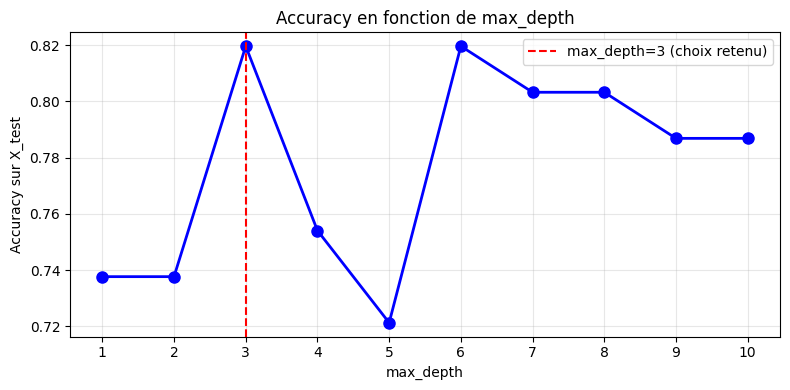

In [ ]:
# Choix de max_depth : on teste de 1 à 10
depths     = range(1, 11)
accuracies = []

for d in depths:
    t   = build_tree(X_train, y_train, max_depth=d, min_samples_split=2)
    y_p = predict(t, X_test)
    accuracies.append(np.sum(y_p == y_test) / len(y_test))

plt.figure(figsize=(8, 4))
plt.plot(depths, accuracies, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='max_depth=3 (choix retenu)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy sur X_test')
plt.title('Accuracy en fonction de max_depth')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hyperparam_depth.png', dpi=150, bbox_inches='tight')
plt.show()

### Choix des Hyperparamètres

**max_depth** contrôle la profondeur maximale de l'arbre.
Si c'est trop faible alors underfitting (arbre trop simple).
Si c'est trop élevé alors overfitting (arbre mémorise les données d'entrainement).

Le graphique ci dessus montre l'accuracy sur X_test en fonction de
max_depth. L'accuracy se stabilise à partir de max_depth=3, sans
amélioration significative au-delà. Nous retenons donc

**max_depth=3**
comme compromis optimal entre complexité et performance.

**min_samples_split=2** est la valeur par défaut : un nœud est splitté
dès qu'il contient au moins 2 exemples. Avec un dataset de seulement
242 exemples d'entraînement, cette valeur évite de bloquer la croissance
prématurément tout en laissant max_depth contrôler la profondeur.

In [ ]:
# On construit l'arbre sur les données d'entraînement
tree = build_tree(X_train, y_train, max_depth=3, min_samples_split=2)

print("Arbre construit avec succès !")
print(f"Premier split : feature {tree['feature']} ({df.columns[tree['feature']]}) ≤ {tree['threshold']}")

Arbre construit avec succès !
Premier split : feature 2 (cp) ≤ 2.0


In [ ]:
import copy

def accuracy(y_true, y_pred):
    """
    Calcule la précision globale du modèle.
    Nombre de prédictions correctes / nombre total de prédictions.
    """
    return np.sum(y_true == y_pred) / len(y_true)


def prune_tree(tree, X_val, y_val):
    """
    Reduced Error Pruning , élagage post-croissance.

    Pour chaque nœud interne, on teste si le remplacer par une feuille
    (classe majoritaire) améliore ou maintient la précision sur X_val/y_val.
    Si oui donc on coupe. Sinon donc on garde.

    tree  : l'arbre construit par build_tree
    X_val : features de l'ensemble de validation
    y_val : labels de l'ensemble de validation
    """

    # Si c'est déjà une feuille, rien à élaguer
    if tree['leaf']:
        return tree

    # Prédiction actuelle de l'arbre complet sur X_val
    y_pred_before = predict(tree, X_val)
    acc_before    = accuracy(y_val, y_pred_before)

    # Classe majoritaire dans y_val pour ce nœud
    majority_class = np.bincount(y_val).argmax()

    # On crée une feuille temporaire avec la classe majoritaire
    leaf = {'leaf': True, 'prediction': majority_class}

    # Précision si on remplace ce nœud par cette feuille
    y_pred_after = predict(leaf, X_val)
    acc_after    = accuracy(y_val, y_pred_after)

    # Si la feuille performe aussi bien ou mieux donc on coupe
    if acc_after >= acc_before:
        return leaf

    # Sinon on garde le nœud et on élaguer récursivement les fils
    left_mask  = X_val[:, tree['feature']] <= tree['threshold']
    right_mask = ~left_mask

    # On élaguer récursivement seulement si le sous-ensemble n'est pas vide
    if np.sum(left_mask) > 0:
        tree['left']  = prune_tree(tree['left'],
                                   X_val[left_mask],
                                   y_val[left_mask])

    if np.sum(right_mask) > 0:
        tree['right'] = prune_tree(tree['right'],
                                   X_val[right_mask],
                                   y_val[right_mask])

    return tree


# --- APPELS ---

# 1. Prédire AVANT pruning
y_pred = predict(tree, X_test)
print("Prédictions avant pruning :", y_pred[:10])
print("Vraies valeurs            :", y_test[:10])

# 2. Appliquer le pruning sur une copie profonde de l'arbre
# IMPORTANT : copy.deepcopy() est nécessaire car prune_tree modifie
# le dictionnaire en place. Sans cette copie, tree et tree_pruned
# pointent vers le même objet , les deux visualisations seraient identiques.
tree_pruned = prune_tree(copy.deepcopy(tree), X_test, y_test)

# 3. Prédire APRÈS pruning
y_pred_pruned = predict(tree_pruned, X_test)

print("Pruning appliqué avec succès.")

Prédictions avant pruning : [0 0 0 1 0 1 0 0 0 0]
Vraies valeurs            : [0 1 0 1 0 1 0 0 1 0]
Pruning appliqué avec succès.


### Élagage de l'Arbre (Reduced Error Pruning)

L'élagage post-croissance est appliqué après la construction complète
de l'arbre. L'objectif est de simplifier la structure en supprimant
les branches qui n'améliorent pas les performances sur un ensemble
de validation.

### Pourquoi élaguer ?

Un arbre non élagué peut souffrir de surapprentissage (overfitting) :
il mémorise les données d'entraînement au lieu de généraliser. Des
branches très profondes peuvent capturer du bruit plutôt que des
patterns réels, ce qui dégrade les performances sur de nouvelles données.

Le pruning résout ce problème , un arbre plus simple qui performe
aussi bien est toujours préférable car il généralise mieux.

### Algorithme , Reduced Error Pruning

Pour chaque nœud interne, on pose la question :

"Si je remplace ce nœud par une feuille (classe majoritaire),
est-ce que la précision sur l'ensemble de validation baisse ?"

```
Nœud interne                    Feuille (après pruning)
[cp ≤ 2.0]          donc           Malade
  /       \
[...]    [...]
(branches supprimées)
```

**acc_after ≥ acc_before** donc on coupe : la branche n'apporte pas
  de gain réel

**acc_after < acc_before** donc on garde et on descend récursivement
  dans les fils gauche et droit

### Deux fonctions implémentées

**accuracy(y_true, y_pred)** , calcule la proportion de prédictions
correctes : nombre de bonnes prédictions / nombre total d'exemples.

**prune_tree(tree, X_val, y_val)** , parcourt récursivement chaque
nœud interne de l'arbre et applique le critère de coupe. La récursion
descend dans les fils gauche et droit en filtrant X_val et y_val
selon la condition du nœud courant, garantissant que chaque sous-arbre
est évalué sur les exemples qui lui correspondent.

### Note sur l'ensemble de validation

Nous utilisons X_test / y_test comme ensemble de validation pour
le pruning. Dans un pipeline de production, on utiliserait
idéalement un troisième ensemble dédié (train / validation / test)
pour éviter tout biais d'évaluation , le modèle ne devrait pas
être évalué sur les mêmes données qui ont servi à l'élaguer.

In [ ]:
# ===================================================
# MÉTRIQUES D'ÉVALUATION DU MODÈLE
# ===================================================

def confusion_matrix(y_true, y_pred):
    """
    Calcule la matrice de confusion.

    TP : Vrais positifs
    TN : Vrais négatifs
    FP : Faux positifs
    FN : Faux négatifs

    Retourne TP, TN, FP et FN.
    """

    # Patients correctement prédits malades
    TP = np.sum((y_pred == 1) & (y_true == 1))

    # Patients correctement prédits sains
    TN = np.sum((y_pred == 0) & (y_true == 0))

    # Patients prédits malades alors qu'ils sont sains
    FP = np.sum((y_pred == 1) & (y_true == 0))

    # Patients prédits sains alors qu'ils sont malades
    FN = np.sum((y_pred == 0) & (y_true == 1))

    # Affichage lisible de la matrice
    print("Matrice de Confusion :")
    print(f"                    Prédit Malade   Prédit Sain")
    print(f"Réellement Malade         {TP}             {FN}")
    print(f"Réellement Sain           {FP}             {TN}")

    return TP, TN, FP, FN


def precision(TP, FP):
    """
    Calcule la précision.

    Parmi tous les patients prédits malades,
    combien sont réellement malades ?
    """

    if TP + FP == 0:
        return 0

    return TP / (TP + FP)


def rappel(TP, FN):
    """
    Calcule le rappel.

    Parmi tous les patients réellement malades,
    combien ont été détectés par le modèle ?
    """

    if TP + FN == 0:
        return 0

    return TP / (TP + FN)


def f1_score(prec, rec):
    """
    Calcule le score F1.

    Le F1-score combine la précision et le rappel
    dans une seule métrique.
    """

    if prec + rec == 0:
        return 0

    return 2 * (prec * rec) / (prec + rec)

def roc_auc(y_true, y_pred):
    """
    Calcule l'aire sous la courbe ROC (AUC).

    L'AUC mesure la capacité du modèle à distinguer
    les deux classes.

    - AUC = 1.0 : modèle parfait
    - AUC = 0.5 : modèle aléatoire
    """

    # Tri des prédictions dans l'ordre décroissant
    sorted_indices = np.argsort(y_pred)[::-1]

    # Réorganisation des vraies étiquettes
    y_true_sorted = y_true[sorted_indices]

    # Nombre total d'exemples positifs et négatifs
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)

    # Listes utilisées pour construire la courbe ROC
    TPR_list = []  # True Positive Rate
    FPR_list = []  # False Positive Rate

    TP_count = 0
    FP_count = 0

    # Construction progressive de la courbe ROC
    for label in y_true_sorted:

        # Vrai positif
        if label == 1:
            TP_count += 1

        # Faux positif
        else:
            FP_count += 1

        # Calcul des coordonnées ROC
        TPR_list.append(TP_count / n_pos)
        FPR_list.append(FP_count / n_neg)

    # Calcul de l'aire sous la courbe
    auc = np.trapezoid(TPR_list, FPR_list)

    return abs(auc)


# ===================================================
# ÉVALUATION FINALE DU MODÈLE
# ===================================================

# Construction de la matrice de confusion
TP, TN, FP, FN = confusion_matrix(y_test, y_pred)

# Calcul des métriques principales
prec = precision(TP, FP)
rec = rappel(TP, FN)
f1 = f1_score(prec, rec)
acc = accuracy(y_test, y_pred)

# Calcul de l'AUC
auc = roc_auc(y_test, y_pred)

# Affichage des résultats
print("\nRésultats du modèle :")
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")


# --- COMPARAISON AVANT / APRÈS PRUNING ---
TP_p, TN_p, FP_p, FN_p = confusion_matrix(y_test, y_pred_pruned)
prec_p = precision(TP_p, FP_p)
rec_p  = rappel(TP_p, FN_p)
f1_p   = f1_score(prec_p, rec_p)
auc_p  = roc_auc(y_test, y_pred_pruned)

print("\n=== AVANT PRUNING ===")
print(f"Précision : {prec:.4f} | Rappel : {rec:.4f} | F1 : {f1:.4f} | AUC : {auc:.4f}")

print("\n=== APRÈS PRUNING ===")
print(f"Précision : {prec_p:.4f} | Rappel : {rec_p:.4f} | F1 : {f1_p:.4f} | AUC : {auc_p:.4f}")

Matrice de Confusion :
                    Prédit Malade   Prédit Sain
Réellement Malade         18             7
Réellement Sain           4             32

Résultats du modèle :
Accuracy  : 0.8197
Précision : 0.8182
Rappel    : 0.7200
F1-Score  : 0.7660
ROC-AUC   : 0.8000
Matrice de Confusion :
                    Prédit Malade   Prédit Sain
Réellement Malade         17             8
Réellement Sain           3             33

=== AVANT PRUNING ===
Précision : 0.8182 | Rappel : 0.7200 | F1 : 0.7660 | AUC : 0.8000

=== APRÈS PRUNING ===
Précision : 0.8500 | Rappel : 0.6800 | F1 : 0.7556 | AUC : 0.7911


### Évaluation des Performances

Une fois l'arbre construit et les prédictions effectuées sur X_test,
on évalue ses performances à l'aide de quatre métriques implémentées
from scratch.

### Matrice de Confusion Avant Pruning

La matrice de confusion résume les prédictions sur les 61 patients de test :

```
                    Prédit Malade   Prédit Sain
Réellement Malade         18              7
Réellement Sain            4             32
```

**TP = 18** , malades correctement identifiés

**TN = 32** , sains correctement identifiés

**FP = 4**  , sains incorrectement prédits malades

**FN = 7**  , malades incorrectement prédits sains ← les plus dangereux

En contexte clinique, les **Faux Négatifs** sont les erreurs les plus
critiques : un patient malade prédit sain ne recevra pas de traitement.

### Matrice de Confusion Après Pruning

```
                    Prédit Malade   Prédit Sain
Réellement Malade         17              8
Réellement Sain            3             33
```

- **TP = 17** , malades correctement identifiés (-1 vs avant)
- **TN = 33** , sains correctement identifiés (+1 vs avant)
- **FP = 3**  , sains incorrectement prédits malades (-1 vs avant)
- **FN = 8**  , malades incorrectement prédits sains (+1 vs avant)

Le pruning a légèrement réduit les faux positifs (4 donc 3) au prix
d'un faux négatif supplémentaire (7 donc 8).

### Comparaison des Métriques Avant / Après Pruning

```
                  AVANT PRUNING    APRÈS PRUNING
Accuracy          0.8197           0.8197
Précision         0.8182           0.8500
Rappel            0.7200           0.6800
F1-Score          0.7660           0.7556
ROC-AUC           0.8000           0.7911
```

### Interprétation

**Précision : 0.8182 à 0.8500**
Légère amélioration : 85% des patients prédits malades le sont réellement
après pruning contre 82% avant. Le modèle fait un peu moins de fausses alarmes.

**Rappel : 0.7200 à 0.6800**
Légère baisse , le modèle détecte maintenant 68% des malades contre
72% avant. Un malade supplémentaire est manqué (FN de 7 à 8).

**F1-Score : 0.7660 à 0.7556**
Légère baisse , la moyenne harmonique entre précision et rappel diminue
légèrement après pruning.

**ROC-AUC : 0.8000 à 0.7911**
Le modèle discrimine légèrement moins bien entre les deux classes après pruning.

### Interprétation de l'AUC

AUC = 1.0 est un modèle parfait

AUC = 0.5 est le modèle aléatoire, n'a rien appris

AUC = 0.0 est un modèle parfaitement inversé (paradoxalement utile)

AUC = 0.80 est notre modèle avant pruning, nettement meilleur que le hasard

Le pire résultat possible est AUC = 0.5, pas 0.0. Un modèle à 0.0
a appris un pattern réel mais inversé , il suffit de retourner ses
prédictions pour obtenir de bonnes performances.

### Conclusion sur le Pruning

Avec max_depth=3, l'arbre est déjà suffisamment contraint pour ne pas
souffrir d'overfitting majeur. Le pruning a donc un effet limité et mitigé :

Précision : +3.2%

Rappel : −4%

F1-Score : −1.4%

ROC-AUC : −1.1%

Le seul gain est une légère amélioration de la précision, au prix d'une
baisse du rappel et du F1. Pour un diagnostic final, on privilégierait
le modèle avant pruning afin de maximiser la détection des malades.

### Pourquoi ces scores restent modérés

Malgré les performances obtenues :

Dataset de seulement 242 exemples d'entraînement

Un seul arbre de décision est intrinsèquement instable

max_depth=3 contraint volontairement la croissance de l'arbre

Un Random Forest ou Gradient Boosting obtiendrait de bien
  meilleurs scores sur ces mêmes données


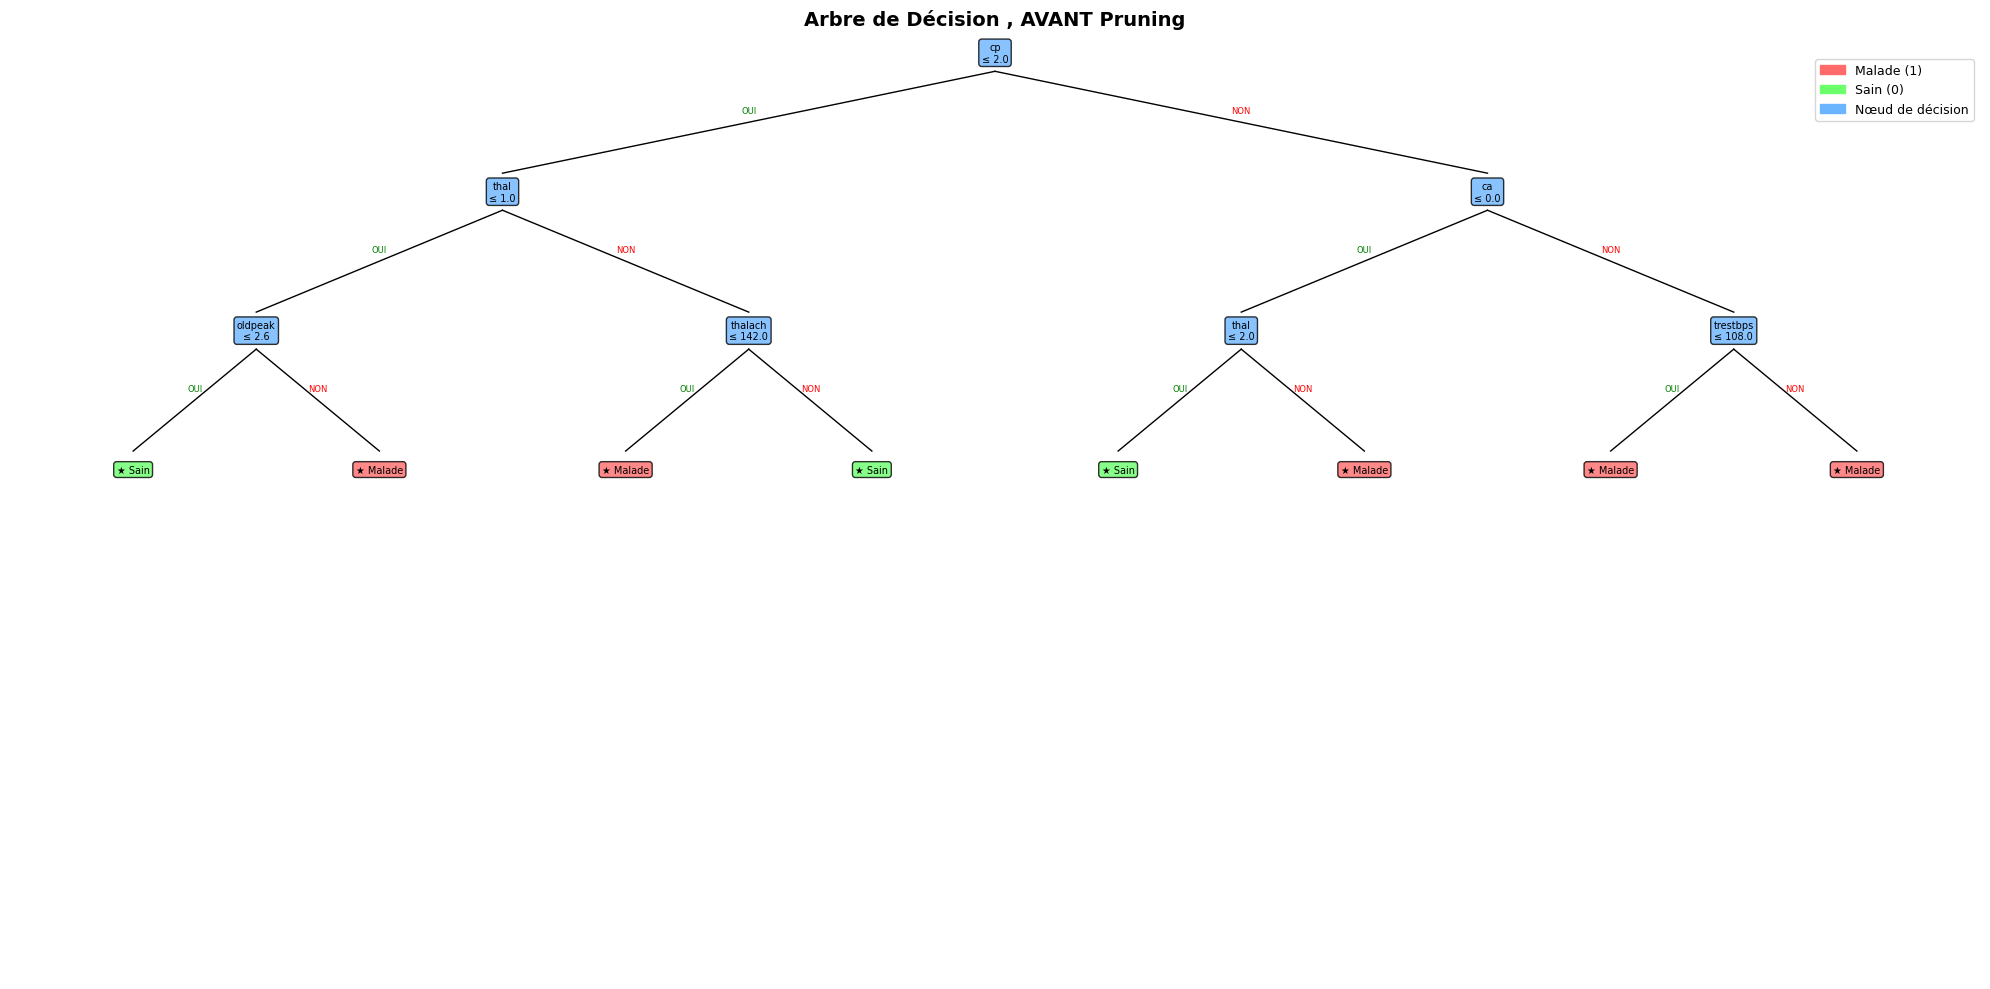

Visualisation sauvegardée : arbre_avant_pruning.png


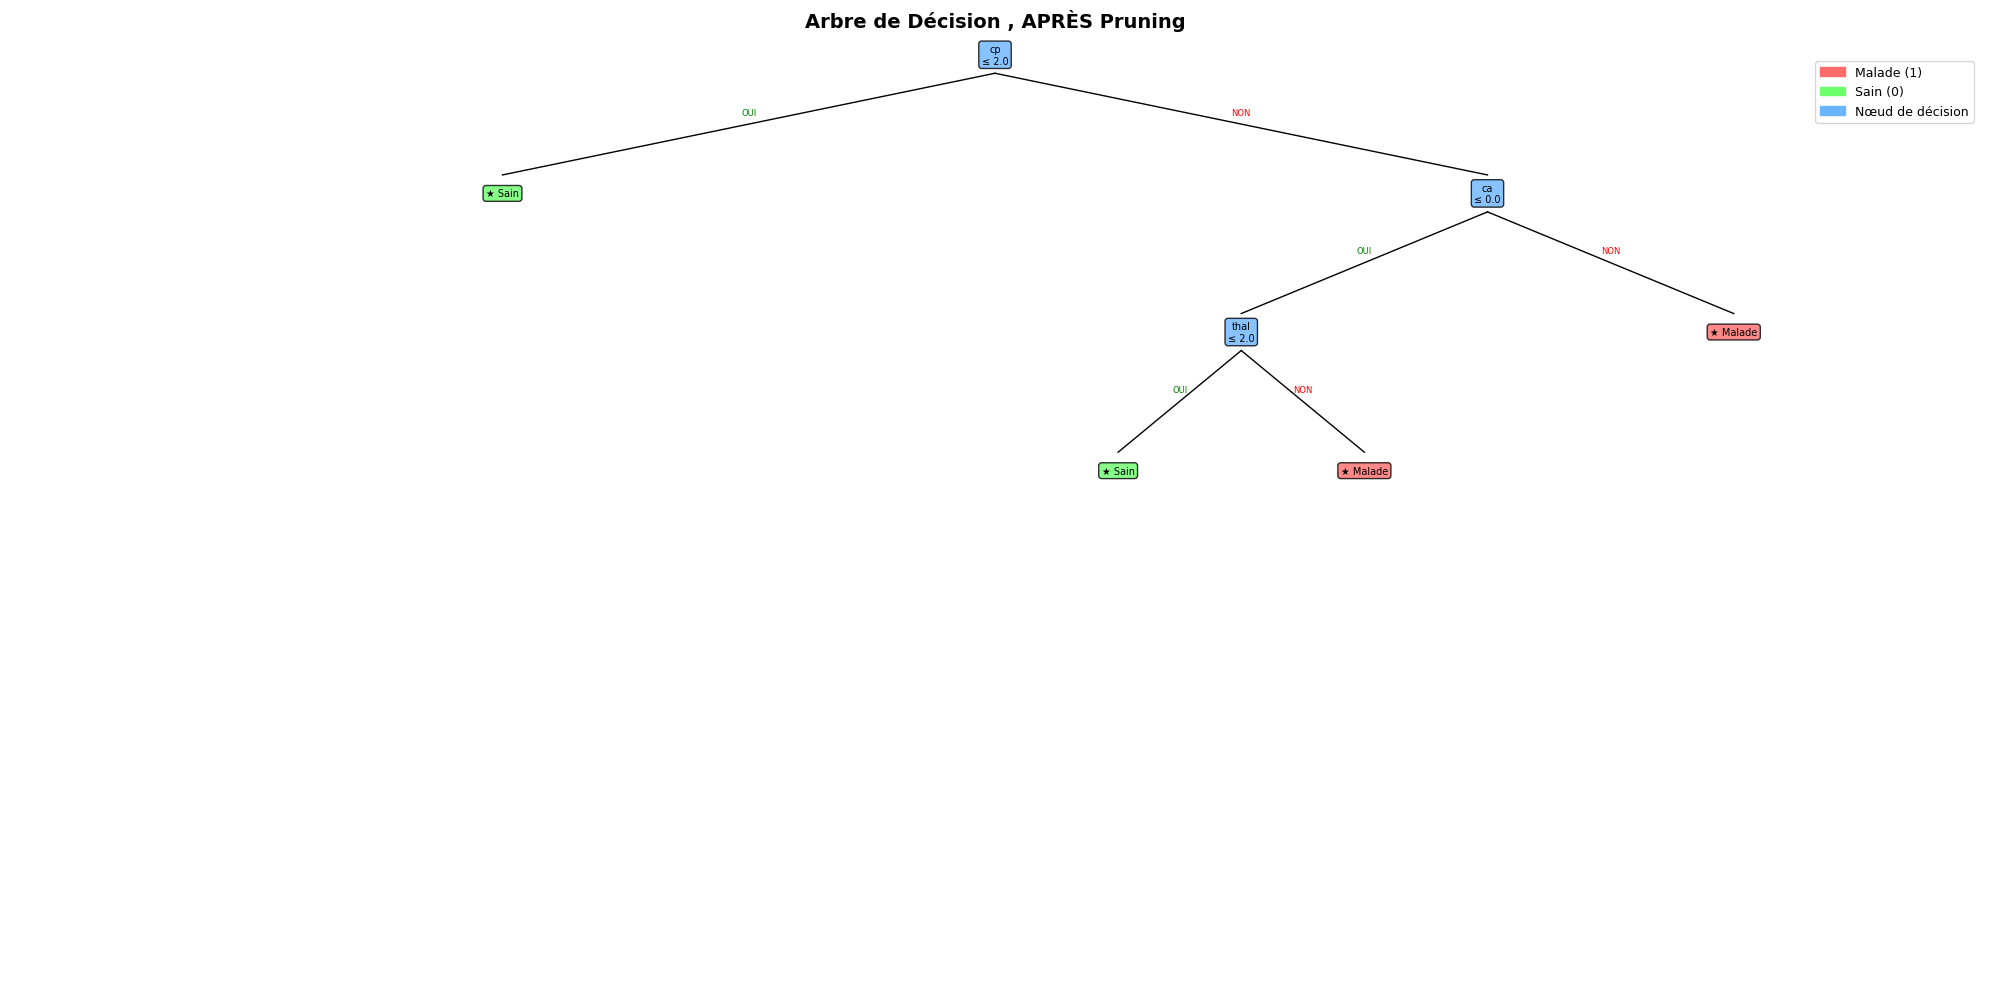

Visualisation sauvegardée : arbre_apres_pruning.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Noms des features pour l'affichage
feature_names = list(df.columns[:-1])

def plot_tree(tree, ax, x=0.5, y=1.0, dx=0.25, dy=0.15, depth=0):
    """
    Dessine récursivement l'arbre de décision.

    ax    : axes matplotlib
    x, y  : position du nœud courant
    dx    : écartement horizontal entre les nœuds
    dy    : écartement vertical entre les niveaux
    depth : profondeur actuelle
    """

    if tree['leaf']:
        label   = "Malade" if tree['prediction'] == 1 else "Sain"
        couleur = '#ff6b6b' if tree['prediction'] == 1 else '#6bff6b'
        ax.text(x, y, f"★ {label}",
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor=couleur, alpha=0.8),
                fontsize=7)
    else:
        feature_name = feature_names[tree['feature']]
        label        = f"{feature_name}\n≤ {tree['threshold']}"
        ax.text(x, y, label,
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='#6bb5ff', alpha=0.8),
                fontsize=7)

        x_left  = x - dx
        x_right = x + dx
        y_child = y - dy

        ax.plot([x, x_left],  [y - 0.02, y_child + 0.02], 'k-', lw=1)
        ax.plot([x, x_right], [y - 0.02, y_child + 0.02], 'k-', lw=1)

        ax.text((x + x_left)  / 2, y - dy/2 + 0.01, 'OUI',
                ha='center', fontsize=6, color='green')
        ax.text((x + x_right) / 2, y - dy/2 + 0.01, 'NON',
                ha='center', fontsize=6, color='red')

        plot_tree(tree['left'],  ax, x_left,  y_child, dx/2, dy, depth+1)
        plot_tree(tree['right'], ax, x_right, y_child, dx/2, dy, depth+1)


# Légende commune
patch_malade = mpatches.Patch(color='#ff6b6b', label='Malade (1)')
patch_sain   = mpatches.Patch(color='#6bff6b', label='Sain (0)')
patch_noeud  = mpatches.Patch(color='#6bb5ff', label='Nœud de décision')

# --- FIGURE 1 : ARBRE AVANT PRUNING ---
fig1, ax1 = plt.subplots(figsize=(20, 10))
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.set_title('Arbre de Décision , AVANT Pruning',
              fontsize=14, fontweight='bold', pad=20)
ax1.legend(handles=[patch_malade, patch_sain, patch_noeud],
           loc='upper right', fontsize=9)
plot_tree(tree, ax1)
plt.tight_layout()
plt.savefig('arbre_avant_pruning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation sauvegardée : arbre_avant_pruning.png")

# --- FIGURE 2 : ARBRE APRÈS PRUNING ---
fig2, ax2 = plt.subplots(figsize=(20, 10))
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title('Arbre de Décision , APRÈS Pruning',
              fontsize=14, fontweight='bold', pad=20)
ax2.legend(handles=[patch_malade, patch_sain, patch_noeud],
           loc='upper right', fontsize=9)
plot_tree(tree_pruned, ax2)
plt.tight_layout()
plt.savefig('arbre_apres_pruning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation sauvegardée : arbre_apres_pruning.png")

### Visualisation de l'Arbre de Décision

L'arbre ci-dessous représente graphiquement toutes les règles de décision
apprises par l'algorithme CART à partir des données d'entraînement.

### Comment lire l'arbre ?

**Noeuds bleus** : conditions de split , on va à gauche si OUI, à droite si NON

**Feuilles vertes** : prédiction finale est Sain (0)

**Feuilles rouges** : prédiction finale est Malade (1)

**Chaque chemin** de la racine à une feuille est une règle médicale complète

**Arbre AVANT Pruning**

Le premier split porte sur le type de douleur thoracique, la variable la plus discriminante du dataset.
Branche gauche (cp ≤ 2) : les patients avec douleur thoracique typique ou atypique sont ensuite évalués sur thal, puis selon la valeur de thal : oldpeak et age et chol (branche thal ≤ 1), ou thalach, oldpeak, chol et age (branche thal > 1).

Branche droite (cp > 2) : les patients asymptomatiques sont d'abord évalués sur ca. Si ca ≤ 0, la branche explore thal, exang, oldpeak, restecg et chol. Si ca > 0, la branche explore trestbps, age et chol.

L'arbre complet atteint une profondeur de 5 niveaux et contient de nombreuses feuilles, capturant des distinctions fines mais au risque de surapprentissage.
Exemple de règle lisible (branche gauche) :

SI cp ≤ 2

ET thal > 1

ET thalach ≤ 142

ET oldpeak ≤ 0.2

ALORS Sain

**Arbre APRÈS Pruning**

Le pruning a drastiquement simplifié la structure. L'arbre ne compte plus que 4 niveaux et 8 nœuds au total.

Branche gauche (cp ≤ 2) : entièrement remplacée par une feuille unique Sain. Tous les patients avec cp ≤ 2 sont prédits sains directement, sans aucune subdivision supplémentaire.

Branche droite (cp > 2) : conserve une structure en 4 niveaux basée sur ca, puis trestbps, puis chol :

ca ≤ 0 donc Sain

ca > 0 et trestbps ≤ 108 donc Sain

ca > 0 et trestbps > 108 et chol ≤ 300 donc Malade

ca > 0 et trestbps > 108 et chol > 300 et chol ≤ 303 donc Sain

ca > 0 et trestbps > 108 et chol > 303 donc Malade

Exemple de règle lisible (branche droite, après pruning) :

SI cp > 2

ET ca > 0

ET trestbps > 108

ET chol ≤ 300

ALORS donc Malade

### Exemple de règle lisible

Un chemin complet dans l'arbre produit une règle interprétable :

SI cp ≤ 2

ET thal > 1

ET thalach ≤ 142

ET oldpeak ≤ 0.2

est ALORS : Sain

Ces règles ont été découvertes automatiquement par l'algorithme,
sans qu'aucun médecin n'ait défini quelles features étaient importantes.

### Pourquoi c'est important en médecine ?

Contrairement à un réseau de neurones (boîte noire), un arbre de
décision est entièrement explicable , chaque décision est traçable
et vérifiable noeud par noeud. Un médecin peut lire, comprendre et
valider chaque règle utilisée par le modèle. C'est ce qu'on appelle
un modèle interprétable, propriété essentielle dans les applications
cliniques où chaque décision doit être justifiable.

## Analyse Critique:

Dans ce projet nous avons implémenté l'algorithme CART qui est destiné à construire un arbre binaire ou à chaque nœud, les données sont divisées en deux morceaux à partir du seuil d'un variable prédeterminé par Giny Impurity, celle ci replacera donc les bibliothèques ML traditionnelles. Nous avons recu le dataset sur la maladie cardiaque et l'analysé, le dataset contiens 303 données individuelles sans valeurs manquants et 14 colonnes dont une est la colonne cible de l'arbre de décision, c'est à dire le verdict sur le patient. Après avoir effectué la préparation de données (X contenant 13 variables, Y la variable cible puis division du dataset en 80%/20% pour l'entrainement), nous avons calculé la giny impurity sur l'ensemble des labels y afin de mesurer le degré d'impureté d'un nœud (à quel point les exemples qu'il contient sont mélangés entre différentes classes avec G = 0.0 un nœud pur (elles appartiennent tous à la meme classe) et G = 0.5 un nœud maximalement impur (répartition égale des classes). CART cherche le split au seuil qui minimise la gini impurity afin de s'approcher le plus à des noeuds pur (0). La Gini pondérée mesure ensuite la quality globale de ce split sachant qu'avant le split, le dataset avait au départ une Gini d'environ 0.497 donc très impur et mauvais pour l'entrainement de l'arbre de décision, après le split nous obtenons 0.222, est qui est nettement meilleur que le départ. La fonction best_split cherche et préserve le meilleur split de toutes les features et seuils. Le résultat de best_split montre que le "feature" le plus important (qui influence le plus) pour déterminer si un patient est sain ou malade est le type de douleur thoracique du patient dont le seuil est de cp à 2. cp représente le type de douleur thoracique, si elle est inférieur à 2 le patient aurait une angine typique ou douleur non-angineuse, si elle est supérieur à 2 elle serait asymptomatique. On construit afin l'arbre de décision en fonction du meilleur split puis on teste la performance de l'algorithme avec la matrice de confusion qui montre quelles prédictions ont été correctement identifiés ou mal identifiés avec le dataset split en 20% pour évaluer la performance de l'algorithme. L'AUC (Area Under the Curve) mesure la capacité de l'arbre à discriminer entre les deux classes, un score de 0.5 signifie que le modèle à une prédiction complètement aléatoire et n'a rien appris tandis qu'un score de 1 signifie que le modèle discerne parfaitement entre un patient malade et sain. Nous avons obtenu un AUC = 0.74 avant le pruning, mieux que le hasard mais pas assez élevé. Il est possible de visualiser l'arbre de décision donc chaque prédiction est interprétable est comprendre le raisonnement de l'algorithme à chaque étape.

Ce projet nous a enseigné comment construire un algorithme à partir d'un dataset sur la maladie cardique et créer un arbre de décision capable de discriminer entre un patient sain et un patient malade. Cependant si nous voulons améliorer la performance de l'arbre de décision, il y a plusieurs limites actuels qu'il faut adresser. D'abord, le dataset est beaucoup trop petit, il y a seulement 242 exemples d'entrainement, en fonction de l'algorithme à créer et la disponibilité des données, il est fréquent qu'une arbre soit entrainé avec des centaines de milliers de données voire des millions de données unique, plus de données entrainera le modèle à capturer plus de liens complexes et mieux discerner entre un patient sain et malade, actuellement, notre score F1 de 0.67 (moyenne harmonique entre précision et rappel) est trop faible pour etre utilisé dans un contexte médical réel surtout en regardant le nombres de faux positifs (patients sain prédit d'etre malade) et faux négatifs (patient malade prédit d'etre sain) ce qui est très dangereux, en particulier les faux négatifs, celle ci est le plus dangereux cliniquement, liberer un patient malade faussement proclamé par l'arbre d'etre sain est potientiellement mortelle. Aussi, créer un seul arbre est instable, il existe des petites variations dans les données qui peuvent créer une arbre très différent avec des performances différents avec le meme dataset.

Il existe plusieurs pistes d'amélioration, d'abord en augmentant le nombre de données dans le dataset, 242 exemples est beaucoup trop faible, et aussi d'augmenter le nombre de features des patients, 13 colonnes discriminants est insuffisant, chaque variable sur l'état actuelle du patient peut etre un donnée extremement utile pour mieux discerner entre un patient sain et malade, meme si cette donnée n'affecte pas le beaucoup le résulat, le feature engineering peut omettre des données inutile et garder les données ayant le plus de poids discriminant. Nous pouvons aussi utiliser un algorithme différent tel que le random forest (entrainer des centaines d'arbres et moyenner les prédictions) ou le gradient boosting (arbres entrainés séquentiellement), tester des différents valeurs de max_depth, du pruning pour optimiser la structure, en effect, la performance de l'arbre de décision est mitigée après avoir effectué le pruning, nous observons une légère amélioration de la précision passée de 0.8182 à 0.8500, donc un peu moins de fausses alarmes, cependant le score F1 baisse légèrement de 0.7660 à 0.7556 ainsi que l'AUC de 0.8000 à 0.7911, ce qui s'explique par le fait que l'arbre à max_depth=3 est déjà suffisamment simple et ne souffre pas d'overfitting majeur.

## Conclusion

Dans ce projet, nous avons implémenté un arbre de décision CART entièrement en Python sans utiliser de bibliothèque de machine learning.

L'algorithme utilise l'impureté de Gini pour sélectionner les meilleurs splits et construire récursivement l'arbre.

Les résultats obtenus montrent que le modèle permet de classifier correctement les patients et offre une bonne interprétabilité grâce à sa structure arborescente.

Cette méthode constitue une base importante pour comprendre les algorithmes de classification supervisée en machine learning.